In [1]:
import os
os.getcwd()


'C:\\Users\\sonu\\Desktop\\big_data\\project\\ML'

In [2]:
print("hello")

hello


In [3]:
import os
import re
import pandas as pd

# Path to raw data
raw_data_dir = r"C:\Users\sonu\Desktop\big_data\project\Original Reddit Data\raw data"

# Quick check
os.listdir(raw_data_dir)


['2019', '2020', '2021', '2022']

In [4]:
pattern = re.compile(r"^(anx|dep|lone|mh|sw)([a-z]+)(\d{2})\.csv$")

found_files = []
for root, dirs, files in os.walk(raw_data_dir):
    for f in files:
        if pattern.match(f.lower()):
            found_files.append(os.path.join(root, f))

len(found_files), found_files[:10]  # show how many and a preview


(217,
 ['C:\\Users\\sonu\\Desktop\\big_data\\project\\Original Reddit Data\\raw data\\2019\\apr\\anxapr19.csv',
  'C:\\Users\\sonu\\Desktop\\big_data\\project\\Original Reddit Data\\raw data\\2019\\apr\\depapr19.csv',
  'C:\\Users\\sonu\\Desktop\\big_data\\project\\Original Reddit Data\\raw data\\2019\\apr\\loneapr19.csv',
  'C:\\Users\\sonu\\Desktop\\big_data\\project\\Original Reddit Data\\raw data\\2019\\apr\\mhapr19.csv',
  'C:\\Users\\sonu\\Desktop\\big_data\\project\\Original Reddit Data\\raw data\\2019\\apr\\swapr19.csv',
  'C:\\Users\\sonu\\Desktop\\big_data\\project\\Original Reddit Data\\raw data\\2019\\aug\\anxaug19.csv',
  'C:\\Users\\sonu\\Desktop\\big_data\\project\\Original Reddit Data\\raw data\\2019\\aug\\depaug19.csv',
  'C:\\Users\\sonu\\Desktop\\big_data\\project\\Original Reddit Data\\raw data\\2019\\aug\\loneaug19.csv',
  'C:\\Users\\sonu\\Desktop\\big_data\\project\\Original Reddit Data\\raw data\\2019\\aug\\mhaug19.csv',
  'C:\\Users\\sonu\\Desktop\\big_data\\pr

In [5]:
records = []

for file_path in found_files:
    file_name = os.path.basename(file_path).lower()
    match = pattern.match(file_name)
    if not match:
        continue
    
    label, month_abbr, year_abbr = match.groups()
    year = 2000 + int(year_abbr)
    
    # Read only needed columns to save memory
    try:
        df = pd.read_csv(file_path, usecols=["author","created_utc","selftext","subreddit","title","timestamp"])
    except Exception as e:
        print(f"⚠️ Skipping {file_name} ({e})")
        continue
    
    df["label"] = label
    df["year"] = year
    df["month"] = month_abbr
    
    records.append(df)

# Merge all
merged_df = pd.concat(records, ignore_index=True)
merged_df.shape


(1825319, 9)

In [6]:
merged_df.head()
merged_df['label'].value_counts()


label
dep     617108
sw      476151
mh      294561
anx     280138
lone    157361
Name: count, dtype: int64

In [10]:
out_path_parquet = r"C:\Users\sonu\Desktop\big_data\project\ML\merged_dataset.parquet"
out_path_csv = r"C:\Users\sonu\Desktop\big_data\project\ML\merged_dataset.csv"

try:
    merged_df.to_parquet(out_path_parquet, index=False)
    print("✅ Saved as Parquet:", out_path_parquet)
except Exception as e:
    print("⚠️ Parquet failed:", e)
    print("➡️ Saving as CSV instead...")
    merged_df.to_csv(out_path_csv, index=False)
    print("✅ Saved as CSV:", out_path_csv)


⚠️ Parquet failed: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.
➡️ Saving as CSV instead...
✅ Saved as CSV: C:\Users\sonu\Desktop\big_data\project\ML\merged_dataset.csv


In [12]:
import pandas as pd

df = pd.read_csv(r"C:\Users\sonu\Desktop\big_data\project\ML\merged_dataset.csv")

# Quick checks
print(df.shape)         # rows, columns
print(df.head())        # first 5 rows
print(df.columns)       # column names


(1825319, 9)
         author  created_utc  \
0    erbush1988   1556632225   
1  weeblybeebly   1556631109   
2    logicminds   1556630422   
3      kweesnaw   1556629580   
4       drekiaa   1556628567   

                                            selftext subreddit  \
0  Hello all.  \n\nMy wife has anxiety and lately...   Anxiety   
1  \n            I wanted to write this because I...   Anxiety   
2                                                NaN   Anxiety   
3  Hi all, so I've been taking Effexor XR 75 MG f...   Anxiety   
4  Hi guys!\n\nI've finally come to the conclusio...   Anxiety   

                                               title            timestamp  \
0                  Wife has anxiety. How can I help?  2019-04-30 23:50:25   
1                           My Anxiety’s Kryptonite.  2019-04-30 23:31:49   
2  Do you guys ever make friends online/apps to a...  2019-04-30 23:20:22   
3  While taking Effexor, is it okay to take Cloni...  2019-04-30 23:06:20   
4  After Acc

In [13]:
df['text'] = df['title'].fillna('') + ' ' + df['selftext'].fillna('')


In [14]:
import re

def clean_text(text):
    text = re.sub(r"http\S+", "", text)  # remove URLs
    text = re.sub(r"\s+", " ", text)     # remove extra spaces
    text = re.sub(r"[^A-Za-z0-9 ]+", "", text)  # remove special chars
    return text.lower()

df['clean_text'] = df['text'].apply(clean_text)


In [16]:
!pip install scikit-learn


     ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
     -- ------------------------------------- 0.5/8.9 MB 11.3 MB/s eta 0:00:01
     ---------- ----------------------------- 2.3/8.9 MB 24.1 MB/s eta 0:00:01
     ------------------------- -------------- 5.7/8.9 MB 40.1 MB/s eta 0:00:01
     -------------------------------------- - 8.6/8.9 MB 45.9 MB/s eta 0:00:01
     ---------------------------------------  8.9/8.9 MB 43.7 MB/s eta 0:00:01
     ---------------------------------------- 8.9/8.9 MB 37.9 MB/s eta 0:00:00
  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl (41.3 MB)
     ---------------------------------------- 0.0/308.4 kB ? eta -:--:--
     ------------------------------------- 308.4/308.4 kB 18.6 MB/s eta 0:00:00
  Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)



[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
print(le.classes_)  # shows mapping


['anx' 'dep' 'lone' 'mh' 'sw']


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label_enc'], test_size=0.2, random_state=42, stratify=df['label_enc']
)


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [2]:
import pandas as pd

# Load the merged dataset from CSV
csv_path = r"C:\Users\sonu\Desktop\big_data\project\ML\merged_dataset.csv"
merged_df = pd.read_csv(csv_path)

print("✅ Loaded merged dataset:", merged_df.shape)
print(merged_df.head())


✅ Loaded merged dataset: (1825319, 9)
         author  created_utc  \
0    erbush1988   1556632225   
1  weeblybeebly   1556631109   
2    logicminds   1556630422   
3      kweesnaw   1556629580   
4       drekiaa   1556628567   

                                            selftext subreddit  \
0  Hello all.  \n\nMy wife has anxiety and lately...   Anxiety   
1  \n            I wanted to write this because I...   Anxiety   
2                                                NaN   Anxiety   
3  Hi all, so I've been taking Effexor XR 75 MG f...   Anxiety   
4  Hi guys!\n\nI've finally come to the conclusio...   Anxiety   

                                               title            timestamp  \
0                  Wife has anxiety. How can I help?  2019-04-30 23:50:25   
1                           My Anxiety’s Kryptonite.  2019-04-30 23:31:49   
2  Do you guys ever make friends online/apps to a...  2019-04-30 23:20:22   
3  While taking Effexor, is it okay to take Cloni...  2019-04-30

In [3]:
import joblib
from sklearn.model_selection import train_test_split

# Assuming your merged dataset is already loaded
# and has 'selftext' (text) + 'label' columns
df = merged_df.copy()

# Encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    df['selftext'].fillna(""),  # text
    df['label_enc'],            # encoded labels
    test_size=0.2,
    random_state=42,
    stratify=df['label_enc']
)

# Vectorize
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Save all pieces
joblib.dump(X_train_vec, "X_train_vec.pkl")
joblib.dump(X_test_vec, "X_test_vec.pkl")
joblib.dump(y_train, "y_train.pkl")
joblib.dump(y_test, "y_test.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
joblib.dump(le, "label_encoder.pkl")

print("✅ Train/test split and vectorized data saved.")


✅ Train/test split and vectorized data saved.


✅ Logistic Regression Results
Accuracy: 0.5991

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.69      0.72     56028
           1       0.55      0.67      0.60    123422
           2       0.62      0.48      0.54     31472
           3       0.57      0.41      0.48     58912
           4       0.59      0.61      0.60     95230

    accuracy                           0.60    365064
   macro avg       0.62      0.57      0.59    365064
weighted avg       0.60      0.60      0.60    365064


Confusion Matrix:
 [[38707  6994   823  5061  4443]
 [ 3762 82397  4909  8620 23734]
 [  722 10111 15201  1165  4273]
 [ 6384 19380  1673 24297  7178]
 [ 1361 30644  1813  3306 58106]]


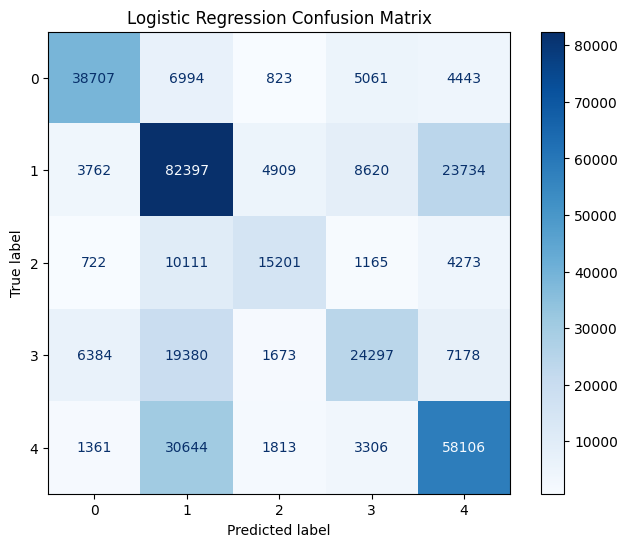

💾 Model saved as logistic_regression_model.pkl


In [4]:
# 📌 Step 1: Import libraries
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import joblib
import matplotlib.pyplot as plt

# 📌 Step 2: Load vectorized data & labels
X_train_vec = joblib.load("X_train_vec.pkl")
X_test_vec = joblib.load("X_test_vec.pkl")
y_train = joblib.load("y_train.pkl")
y_test = joblib.load("y_test.pkl")

# 📌 Step 3: Train Logistic Regression
log_reg = LogisticRegression(max_iter=1000, n_jobs=-1)
log_reg.fit(X_train_vec, y_train)

# 📌 Step 4: Evaluate
y_pred = log_reg.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)
conf_matrix = confusion_matrix(y_test, y_pred)

print("✅ Logistic Regression Results")
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", conf_matrix)

# 📌 Step 5: Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=log_reg.classes_)
fig, ax = plt.subplots(figsize=(8,6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# 📌 Step 6: Save model
joblib.dump(log_reg, "logistic_regression_model.pkl")
print("💾 Model saved as logistic_regression_model.pkl")


In [6]:
!pip install seaborn


     ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
     - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
     - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
     ------- ----------------------------- 61.4/294.9 kB 409.6 kB/s eta 0:00:01
     ------- ----------------------------- 61.4/294.9 kB 409.6 kB/s eta 0:00:01
     ------- ----------------------------- 61.4/294.9 kB 409.6 kB/s eta 0:00:01
     ---------- -------------------------- 81.9/294.9 kB 286.7 kB/s eta 0:00:01
     ---------- -------------------------- 81.9/294.9 kB 286.7 kB/s eta 0:00:01
     ---------- -------------------------- 81.9/294.9 kB 286.7 kB/s eta 0:00:01
     ----------- ------------------------- 92.2/294.9 kB 218.5 kB/s eta 0:00:01
     ----------- ------------------------- 92.2/294.9 kB 218.5 kB/s eta 0:00:01
     ------------- ---------------------- 112.6/294.9 kB 218.3 kB/s eta 0:00:01
     ------------- ---------------------- 112.6/294.9 kB 21


[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



✅ Logistic Regression Results
Accuracy: 0.5991

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.69      0.72     56028
           1       0.55      0.67      0.60    123422
           2       0.62      0.48      0.54     31472
           3       0.57      0.41      0.48     58912
           4       0.59      0.61      0.60     95230

    accuracy                           0.60    365064
   macro avg       0.62      0.57      0.59    365064
weighted avg       0.60      0.60      0.60    365064


Confusion Matrix:


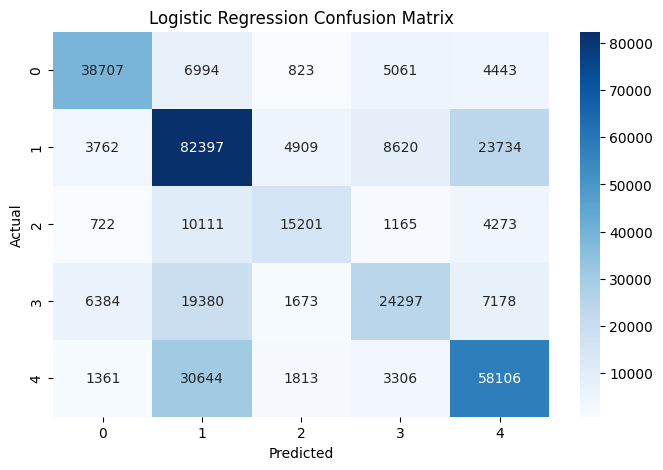


✅ SVM Results
Accuracy: 0.5998

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.71      0.72     56028
           1       0.56      0.66      0.61    123422
           2       0.61      0.48      0.54     31472
           3       0.59      0.37      0.46     58912
           4       0.58      0.63      0.61     95230

    accuracy                           0.60    365064
   macro avg       0.62      0.57      0.59    365064
weighted avg       0.60      0.60      0.60    365064


Confusion Matrix:


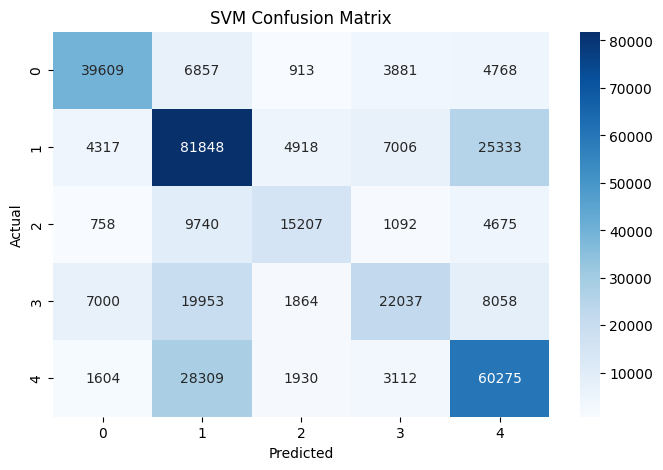

KeyboardInterrupt: 

In [7]:
# 📌 Step 0: Imports
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 📌 Step 1: Load data
X_train_vec = joblib.load("X_train_vec.pkl")
X_test_vec = joblib.load("X_test_vec.pkl")
y_train = joblib.load("y_train.pkl")
y_test = joblib.load("y_test.pkl")

# Dictionary to store models and results
models = {
    "Logistic Regression": joblib.load("logistic_regression_model.pkl"),
    "SVM": LinearSVC(max_iter=5000),
    "Random Forest": RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
}

results = {}

# 📌 Step 2: Train and evaluate
for name, model in models.items():
    if name != "Logistic Regression":
        model.fit(X_train_vec, y_train)  # train SVM and RF
        joblib.dump(model, f"{name.replace(' ','_').lower()}_model.pkl")
    y_pred = model.predict(X_test_vec)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n✅ {name} Results")
    print("Accuracy:", round(acc,4))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nConfusion Matrix:")
    plt.figure(figsize=(8,5))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# 📌 Step 3: Compare models
plt.figure(figsize=(7,5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Classical ML Model Accuracy Comparison")
plt.show()


✅ Random Forest Results
Accuracy: 0.53675

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.62      0.68      3085
           1       0.47      0.76      0.58      6867
           2       0.65      0.25      0.36      1732
           3       0.63      0.20      0.30      3177
           4       0.55      0.50      0.52      5139

    accuracy                           0.54     20000
   macro avg       0.61      0.46      0.49     20000
weighted avg       0.58      0.54      0.52     20000



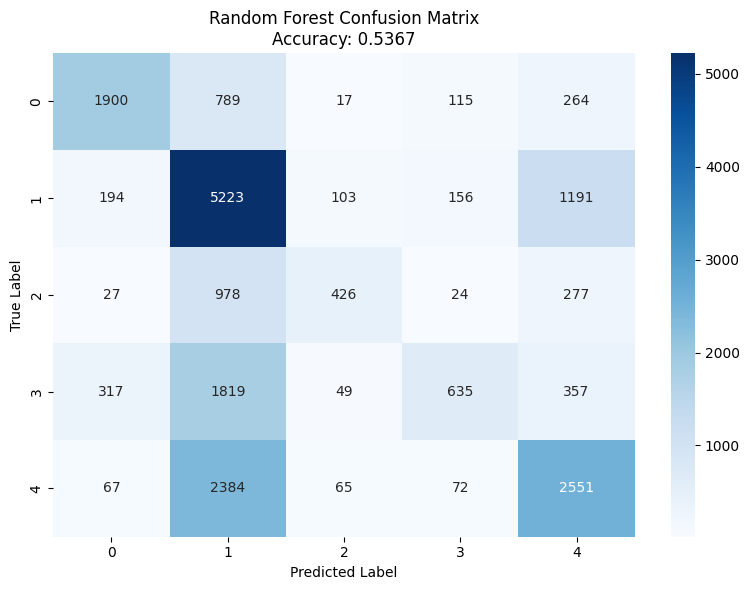

💾 Random Forest model saved as random_forest_model.pkl


In [10]:
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Load vectorized data
# -------------------------
X_train_vec = joblib.load("X_train_vec.pkl")
X_test_vec = joblib.load("X_test_vec.pkl")
y_train = joblib.load("y_train.pkl")
y_test = joblib.load("y_test.pkl")

# -------------------------
# Use subset to avoid memory issues
# -------------------------
X_train_subset = X_train_vec[:100000]
y_train_subset = y_train[:100000]
X_test_subset = X_test_vec[:20000]
y_test_subset = y_test[:20000]

# -------------------------
# Train Random Forest
# -------------------------
# rf = RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
rf = RandomForestClassifier(class_weight='balanced', n_estimators=200, max_depth=None, n_jobs=-1, random_state=42)

rf.fit(X_train_subset, y_train_subset)

# -------------------------
# Predict & Evaluate
# -------------------------
y_pred = rf.predict(X_test_subset)
accuracy = accuracy_score(y_test_subset, y_pred)
print("✅ Random Forest Results")
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test_subset, y_pred))

# -------------------------
# Confusion Matrix Heatmap
# -------------------------
cm = confusion_matrix(y_test_subset, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=sorted(y_test_subset.unique()), yticklabels=sorted(y_test_subset.unique()))
plt.title(f"Random Forest Confusion Matrix\nAccuracy: {accuracy:.4f}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# -------------------------
# Save model
# -------------------------
joblib.dump(rf, "random_forest_model.pkl")
print("💾 Random Forest model saved as random_forest_model.pkl")


In [3]:
import os

folder_path = r"C:\Users\sonu\Desktop\big_data\project\Original Reddit Data\Labelled Data"
print(os.listdir(folder_path))


['LD DA 1.csv', 'LD EL1.csv', 'LD PF1.csv', 'LD TS 1.csv', 'Meta Labelled data kaggel.rtf']


In [5]:
# Step 1: Install XGBoost if not installed
!pip install xgboost

# Step 2: Load preprocessed data
import joblib
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# Load saved train/test data
X_train_vec = joblib.load("X_train_vec.pkl")
X_test_vec = joblib.load("X_test_vec.pkl")
y_train = joblib.load("y_train.pkl")
y_test = joblib.load("y_test.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")
le = joblib.load("label_encoder.pkl")

print("✅ Data loaded successfully!")

# Step 3: Train XGBoost model
xgb_model = XGBClassifier(
    max_depth=6,
    learning_rate=0.1,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    use_label_encoder=False
)

xgb_model.fit(X_train_vec, y_train)

# Step 4: Predictions
y_pred = xgb_model.predict(X_test_vec)

# Step 5: Evaluation
print("🔹 Accuracy:", accuracy_score(y_test, y_pred))
print("\n🔹 Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))
print("\n🔹 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Step 6: Save results for Power BI
results = pd.DataFrame({
    "y_true": le.inverse_transform(y_test),
    "y_pred": le.inverse_transform(y_pred)
})
results.to_csv("xgboost_predictions.csv", index=False)

metrics_summary = {
    "Model": ["XGBoost"],
    "Accuracy": [accuracy_score(y_test, y_pred)]
}
pd.DataFrame(metrics_summary).to_csv("xgboost_metrics.csv", index=False)

print("\n✅ Results saved: 'xgboost_predictions.csv' and 'xgboost_metrics.csv'")



[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Data loaded successfully!


C:\Users\sonu\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [13:24:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


KeyboardInterrupt: 

In [8]:
# Step 1: Install XGBoost if needed
!pip install xgboost scikit-learn pandas joblib

# Step 2: Imports
import joblib
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
from sklearn.model_selection import train_test_split

# Step 3: Load preprocessed data
X_train_vec = joblib.load("X_train_vec.pkl")
X_test_vec = joblib.load("X_test_vec.pkl")
y_train = joblib.load("y_train.pkl")
y_test = joblib.load("y_test.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")
le = joblib.load("label_encoder.pkl")

print("✅ Data loaded successfully!")
print("Training samples:", X_train_vec.shape[0])
print("Test samples:", X_test_vec.shape[0])

# Step 4: Create small validation set from training set
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_vec, y_train, test_size=0.1, random_state=42, stratify=y_train
)

# Step 5: Convert to DMatrix
dtrain = xgb.DMatrix(X_tr, label=y_tr)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test_vec, label=y_test)

# Step 6: XGBoost parameters
params = {
    'objective': 'multi:softmax',      # multi-class classification
    'num_class': len(le.classes_),     # number of classes
    'max_depth': 8,
    'eta': 0.05,
    'subsample': 0.85,
    'colsample_bytree': 0.85,
    'eval_metric': 'mlogloss'
}

watchlist = [(dtrain, 'train'), (dval, 'eval')]

# Step 7: Train with early stopping
print("⏳ Training XGBoost...")
bst = xgb.train(
    params,
    dtrain,
    num_boost_round=500,
    evals=watchlist,
    early_stopping_rounds=20,
    verbose_eval=10
)
print("✅ Training finished!")

# Step 8: Predictions on test set
y_pred = bst.predict(dtest)

# Step 9: Accuracy metrics
acc = accuracy_score(y_test, y_pred)
print("\n🔹 Test Accuracy:", acc)
print("\n🔹 Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))
print("\n🔹 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Step 10: Save predictions and metrics for Power BI
results = pd.DataFrame({
    "y_true": le.inverse_transform(y_test),
    "y_pred": le.inverse_transform(y_pred.astype(int))
})
results.to_csv("xgboost_predictions.csv", index=False)

metrics_summary = {
    "Model": ["XGBoost"],
    "Accuracy": [acc]
}
pd.DataFrame(metrics_summary).to_csv("xgboost_metrics.csv", index=False)

# Step 11: Save trained model
bst.save_model("xgboost_model.json")

print("\n✅ Predictions, metrics, and model saved for Power BI")



[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Data loaded successfully!
Training samples: 1460255
Test samples: 365064
⏳ Training XGBoost...
[0]	train-mlogloss:1.58749	eval-mlogloss:1.58776
[10]	train-mlogloss:1.41393	eval-mlogloss:1.41678
[20]	train-mlogloss:1.31598	eval-mlogloss:1.32117
[30]	train-mlogloss:1.25272	eval-mlogloss:1.26012
[40]	train-mlogloss:1.21112	eval-mlogloss:1.22062
[50]	train-mlogloss:1.18229	eval-mlogloss:1.19376
[60]	train-mlogloss:1.15981	eval-mlogloss:1.17329
[70]	train-mlogloss:1.14227	eval-mlogloss:1.15773
[80]	train-mlogloss:1.12812	eval-mlogloss:1.14551
[90]	train-mlogloss:1.11608	eval-mlogloss:1.13529
[100]	train-mlogloss:1.10587	eval-mlogloss:1.12680
[110]	train-mlogloss:1.09692	eval-mlogloss:1.11941
[120]	train-mlogloss:1.08879	eval-mlogloss:1.11295
[130]	train-mlogloss:1.08159	eval-mlogloss:1.10729
[140]	train-mlogloss:1.07490	eval-mlogloss:1.10214
[150]	train-mlogloss:1.06873	eval-mlogloss:1.09747
[160]	train-mlogloss:1.06306	eval-mlogloss:1.09324
[170]	train-mlogloss:1.05785	eval-mlogloss:1.08

In [ ]:
+